In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
train_df = pd.read_csv("/content/drive/My Drive/train.csv")
test_df = pd.read_csv("/content/drive/My Drive/test.csv")
train_df
test_df

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,24,WALKING_UPSTAIRS
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,24,WALKING_UPSTAIRS
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,24,WALKING_UPSTAIRS
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,24,WALKING_UPSTAIRS


In [8]:
print('null values:',train_df.isnull().values.sum())
train_df.dtypes
print('null values:',test_df.isnull().values.sum())
test_df.dtypes

null values: 0
null values: 0


,0
tBodyAcc-mean()-X,float64
tBodyAcc-mean()-Y,float64
tBodyAcc-mean()-Z,float64
tBodyAcc-std()-X,float64
tBodyAcc-std()-Y,float64
...,...
"angle(X,gravityMean)",float64
"angle(Y,gravityMean)",float64
"angle(Z,gravityMean)",float64
subject,int64


In [9]:
print('Number of duplicates in train set:{}'.format(sum(train_df.duplicated())))
print('Number of duplicates in test set:{}'.format(sum(test_df.duplicated())))

Number of duplicates in train set:0
Number of duplicates in test set:0


In [10]:
train_df['subject'].groupby(train_df['subject']).count()

,subject
subject,
1,347
3,341
5,302
6,325
7,308
8,281
11,316
14,323
15,328


In [12]:
train_df['subject'].groupby(test_df['subject']).count()

,subject
subject,
2.0,302
4.0,317
9.0,288
10.0,294
12.0,320
13.0,327
18.0,364
20.0,354
24.0,381


<ipython-input-20-6fb03f6de598>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df["subject"], palette="viridis")


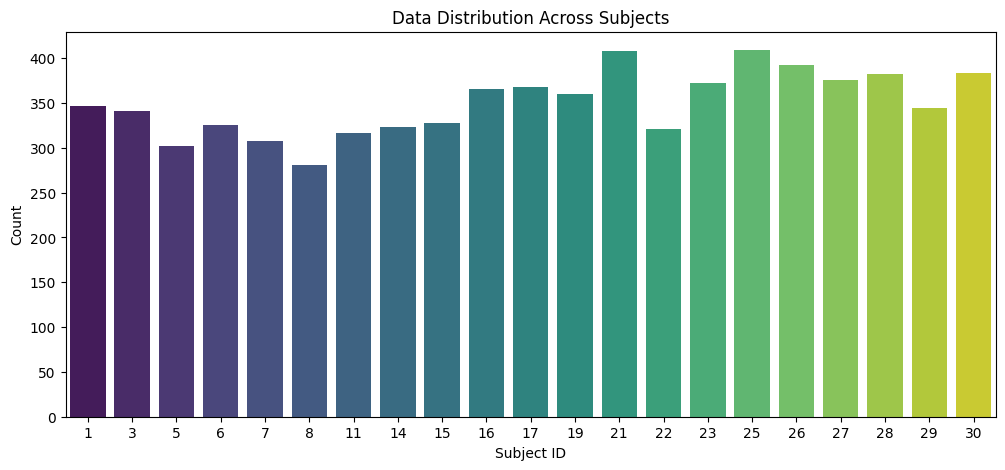

In [20]:
plt.figure(figsize=(12, 5))
sns.countplot(x=train_df["subject"], palette="viridis")
plt.title("Data Distribution Across Subjects")
plt.xlabel("Subject ID")
plt.ylabel("Count")
plt.show()


In [13]:
train_df['Activity'].groupby(train_df['Activity']).size()

,Activity
Activity,
LAYING,1407
SITTING,1286
STANDING,1374
WALKING,1226
WALKING_DOWNSTAIRS,986
WALKING_UPSTAIRS,1073


<ipython-input-34-08a20e25b594>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['Activity'], order=train_df['Activity'].value_counts().index, palette="coolwarm")


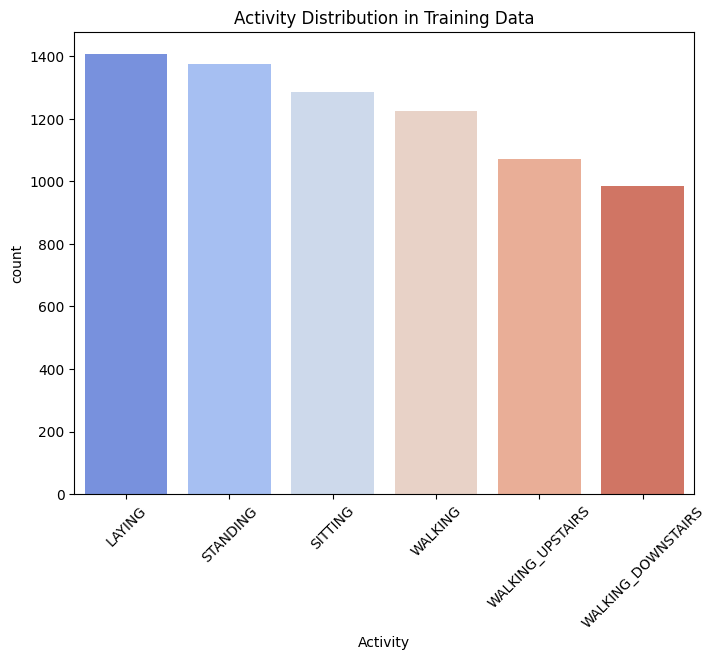

In [34]:
plt.figure(figsize=(8,6))
sns.countplot(x=train_df['Activity'], order=train_df['Activity'].value_counts().index, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Activity Distribution in Training Data")
plt.show()


<Axes: >

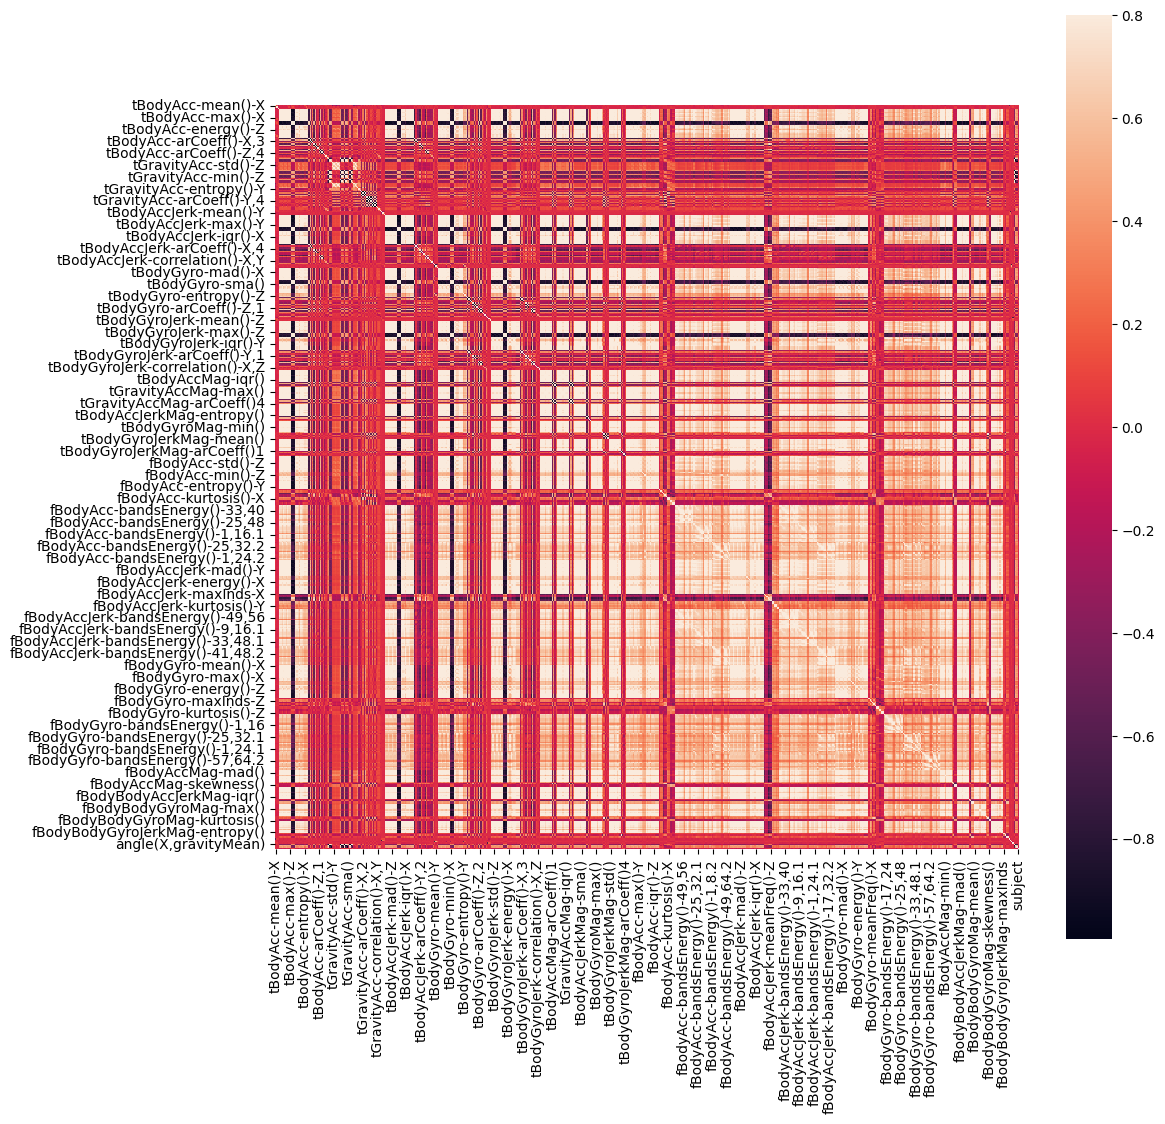

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = train_df.corr(numeric_only=True)
f,ax=plt.subplots(figsize=(12,12))
sns.heatmap(corr,vmax=0.8,square=True)



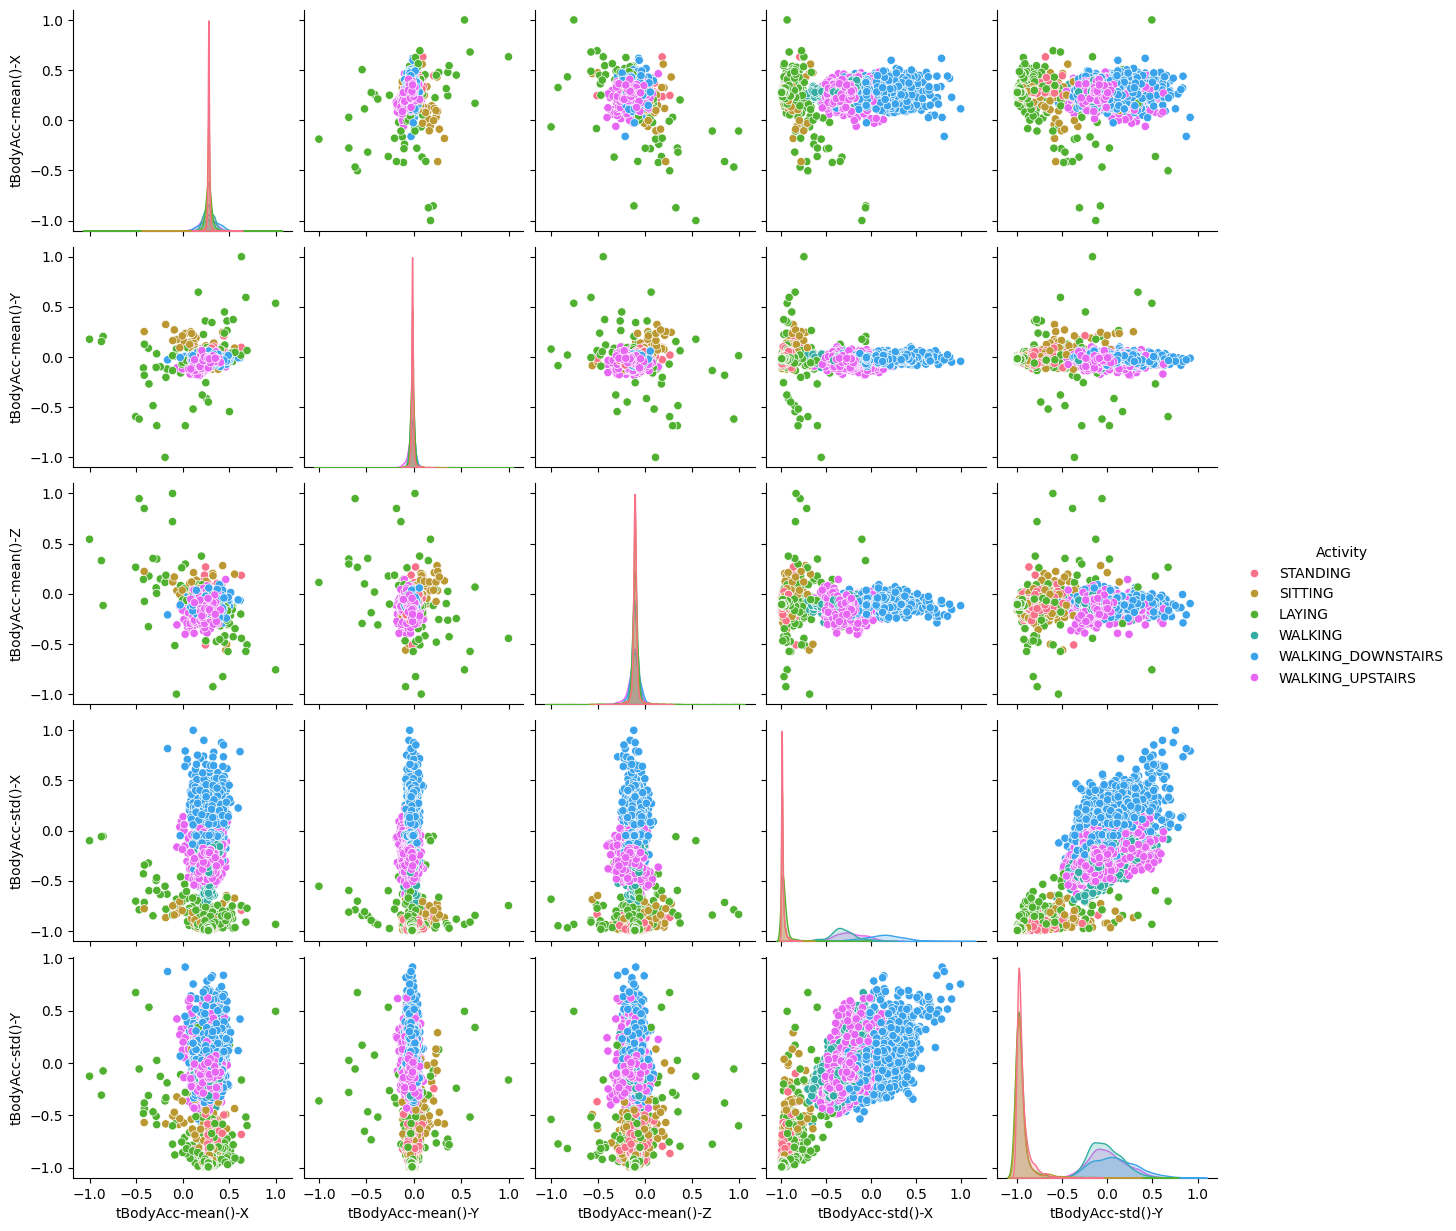

In [23]:
sns.pairplot(train_df[['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'Activity']], hue="Activity", palette="husl")
plt.show()


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

X_train=train_df.drop('Activity',axis=1)
Y_train=train_df['Activity']
X_test=test_df.drop('Activity',axis=1)
Y_test=test_df['Activity']

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7472 - loss: 0.6562 - val_accuracy: 0.9209 - val_loss: 0.2050
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9550 - loss: 0.1291 - val_accuracy: 0.9369 - val_loss: 0.1630
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9589 - loss: 0.1048 - val_accuracy: 0.9420 - val_loss: 0.1501
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9591 - loss: 0.1025 - val_accuracy: 0.9386 - val_loss: 0.1609
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9730 - loss: 0.0720 - val_accuracy: 0.9454 - val_loss: 0.1548
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9687 - loss: 0.0873 - val_accuracy: 0.9423 - val_loss: 0.1669
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9789 - loss: 0.0635 - val_accuracy: 0.9413 - val_loss: 0.1632
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9736 - loss: 0.0662 - val_accuracy: 0.94

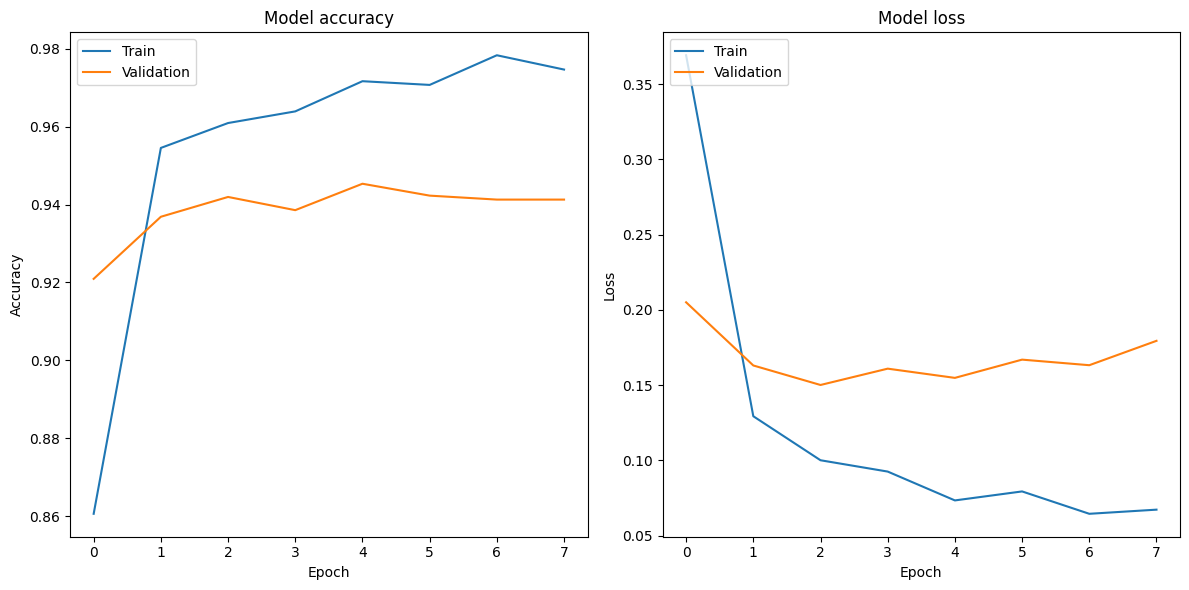

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_lstm_model(input_shape, output_shape):
    model = Sequential()
    model.add(LSTM(128, input_shape=input_shape))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(output_shape, activation='softmax'))
    return model

def train_lstm_model(X_train, Y_train, X_val, Y_val, batch_size=32, epochs=50):
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]), len(np.unique(Y_train)))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_val, Y_val), callbacks=[early_stopping], verbose=1)
    return model, history

X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Train LSTM model
lstm_model, lstm_history = train_lstm_model(X_train_reshaped, Y_train_encoded,
                                            X_test_reshaped, Y_test_encoded)

# Plot training and validation curves
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Testing Accuracy: 0.9419748897183576


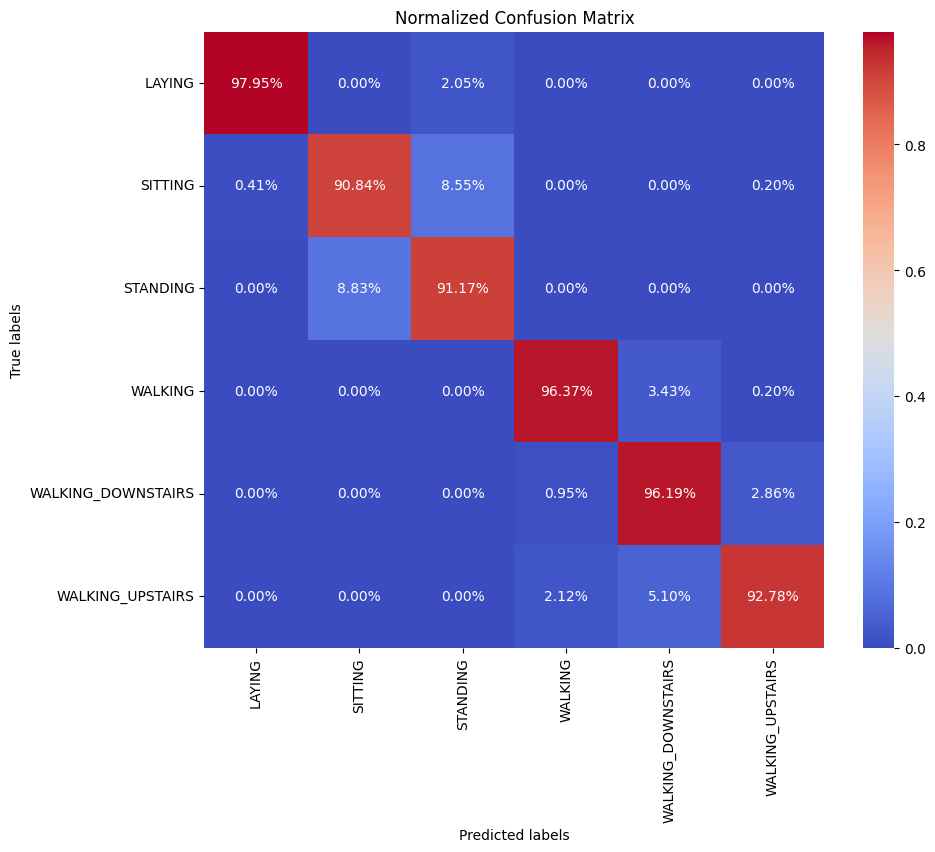

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, Y_test):
    Y_pred_prob = model.predict(X_test)
    Y_pred = np.argmax(Y_pred_prob, axis=1)
    testing_accuracy = accuracy_score(Y_test, Y_pred)
    print("Testing Accuracy:", testing_accuracy)
    conf_matrix = confusion_matrix(Y_test, Y_pred)


    # Normalize confusion matrix
    conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Display confusion matrix as heatmap with percentages
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_norm, annot=True, fmt='.2%', cmap='coolwarm',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Normalized Confusion Matrix')
    plt.show()

    return testing_accuracy, conf_matrix

# Evaluate LSTM model
testing_accuracy, conf_matrix = evaluate_model(lstm_model, X_test_reshaped, Y_test_encoded)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


230/230 ━━━━━━━━━━━━━━━━━━━━ 56s 236ms/step - accuracy: 0.5727 - loss: 0.9524 - val_accuracy: 0.7034 - val_loss: 0.6195
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 66s 167ms/step - accuracy: 0.7651 - loss: 0.5482 - val_accuracy: 0.7384 - val_loss: 0.6164
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 169ms/step - accuracy: 0.7835 - loss: 0.5053 - val_accuracy: 0.7475 - val_loss: 0.6063
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 173ms/step - accuracy: 0.7931 - loss: 0.4808 - val_accuracy: 0.7279 - val_loss: 0.6304
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 175ms/step - accuracy: 0.7591 - loss: 0.5769 - val_accuracy: 0.7326 - val_loss: 0.6386
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 40s 172ms/step - accuracy: 0.7663 - loss: 0.5349 - val_accuracy: 0.7523 - val_loss: 0.6079
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 39s 171ms/step - accuracy: 0.7998 - loss: 0.4714 - val_accuracy: 0.5175 - val_loss: 1.2621
Epoch 8/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 41s 171ms/step - accuracy: 0.6312 - loss: 0.8909 - val

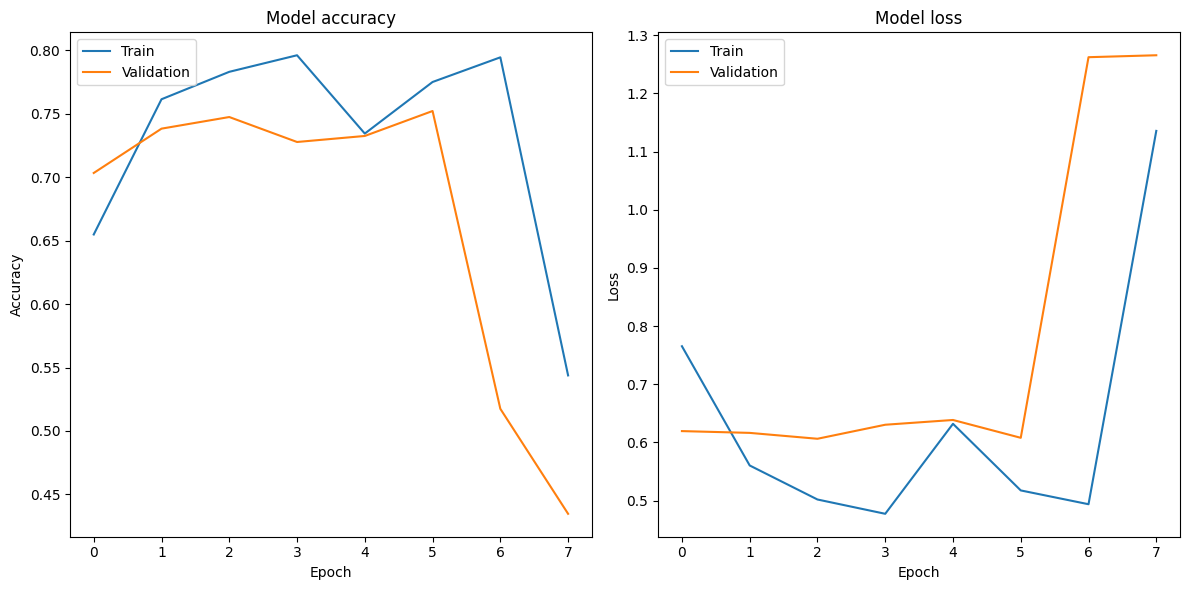

93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step
Testing Accuracy: 0.7475398710553105


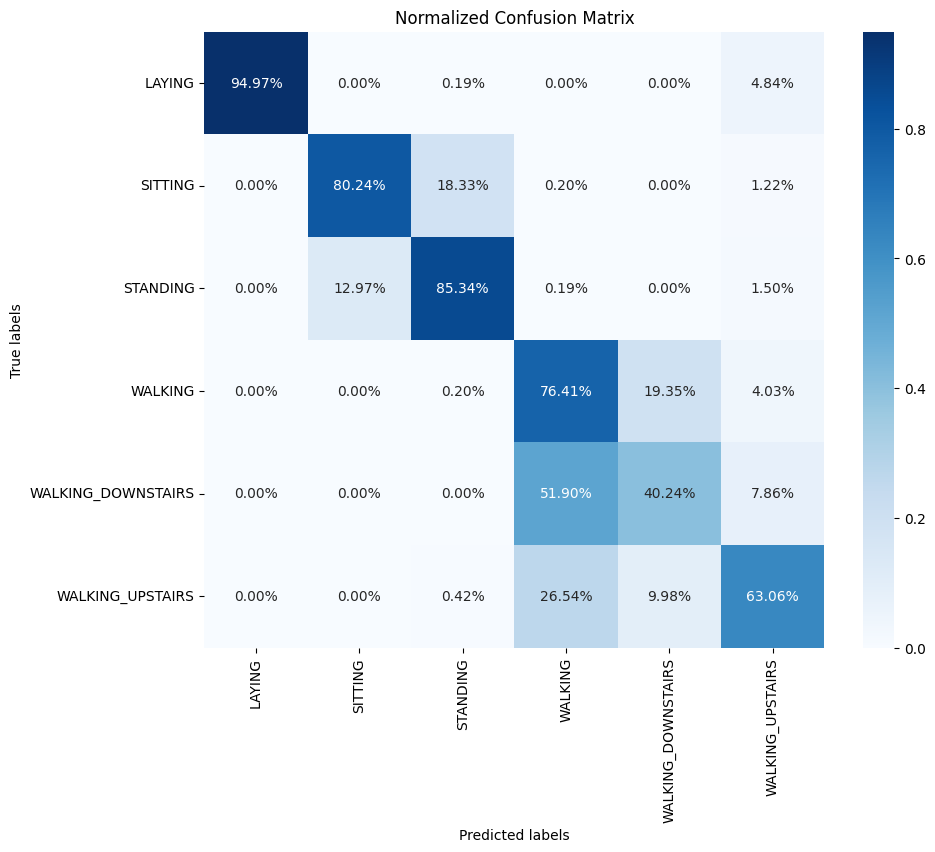

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Assuming the data is loaded and preprocessed similarly to the LSTM example

# Define the RNN model
def build_rnn_model(input_shape, output_shape):
    model = Sequential()
    model.add(SimpleRNN(128, input_shape=input_shape))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(output_shape, activation='softmax'))
    return model

# Train the RNN model
def train_rnn_model(X_train, Y_train, X_val, Y_val, batch_size=32, epochs=50):
    model = build_rnn_model((X_train.shape[1], X_train.shape[2]), len(np.unique(Y_train)))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_val, Y_val), callbacks=[early_stopping], verbose=1)
    return model, history

# Reshape data for RNN
X_train_reshaped = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_reshaped = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Train the RNN model
rnn_model, rnn_history = train_rnn_model(X_train_reshaped, Y_train_encoded,
                                          X_test_reshaped, Y_test_encoded)

# Plot training and validation curves
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

# Evaluation function for RNN model
def evaluate_rnn_model(model, X_test, Y_test):
    Y_pred_prob = model.predict(X_test)
    Y_pred = np.argmax(Y_pred_prob, axis=1)
    testing_accuracy = accuracy_score(Y_test, Y_pred)
    print("Testing Accuracy:", testing_accuracy)
    conf_matrix = confusion_matrix(Y_test, Y_pred)

    # Normalize confusion matrix
    conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Display confusion matrix as heatmap with percentages
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Normalized Confusion Matrix')
    plt.show()

    return testing_accuracy, conf_matrix

# Evaluate the RNN model
testing_accuracy, conf_matrix = evaluate_rnn_model(rnn_model, X_test_reshaped, Y_test_encoded)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.7903 - loss: 0.5459 - val_accuracy: 0.9148 - val_loss: 0.2101
Epoch 2/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9533 - loss: 0.1189 - val_accuracy: 0.9457 - val_loss: 0.1456
Epoch 3/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9649 - loss: 0.0937 - val_accuracy: 0.9260 - val_loss: 0.1938
Epoch 4/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.9664 - loss: 0.0812 - val_accuracy: 0.9250 - val_loss: 0.2312
Epoch 5/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9689 - loss: 0.0776 - val_accuracy: 0.9444 - val_loss: 0.1579
Epoch 6/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9708 - loss: 0.0776 - val_accuracy: 0.9393 - val_loss: 0.1667
Epoch 7/50
230/230 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9728 - loss: 0.0719 - val_accuracy: 0.9396 - val_loss: 0.1833


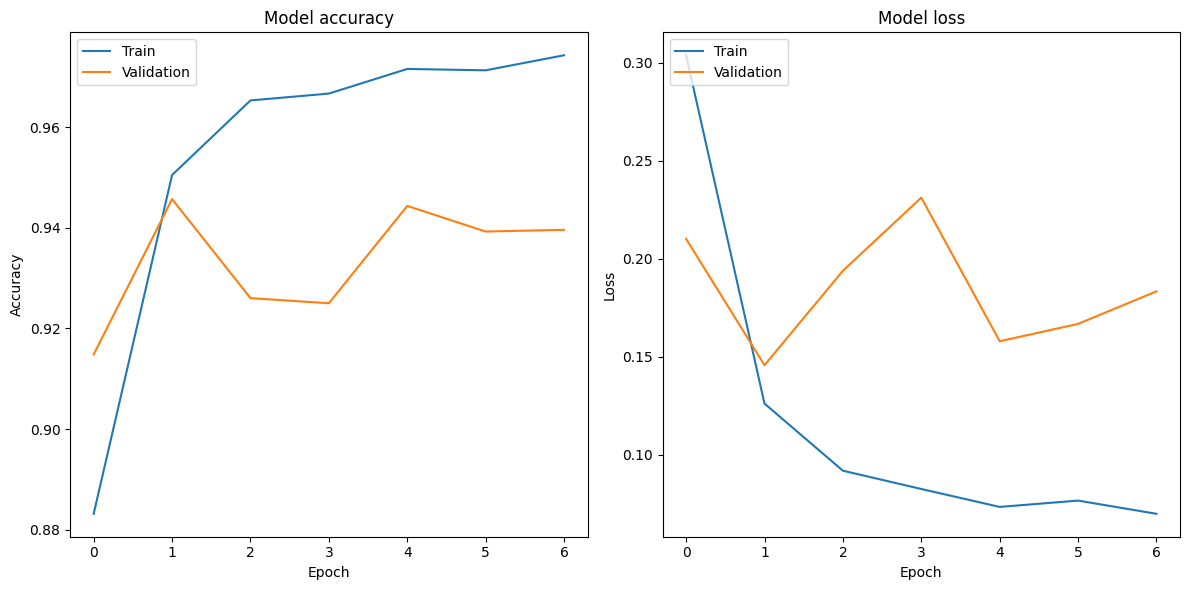

In [35]:
from tensorflow.keras.layers import Bidirectional

def build_bidirectional_rnn_model(input_shape, output_shape):
    model = Sequential()
    model.add(Bidirectional(LSTM(128), input_shape=input_shape))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(output_shape, activation='softmax'))
    return model

def train_bidirectional_rnn_model(X_train, Y_train, X_val, Y_val, batch_size=32, epochs=50):
    model = build_bidirectional_rnn_model((X_train.shape[1], X_train.shape[2]), len(np.unique(Y_train)))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_val, Y_val), callbacks=[early_stopping], verbose=1)
    return model, history

X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Train Bidirectional RNN model
bidirectional_rnn_model, bidirectional_rnn_history = train_bidirectional_rnn_model(X_train_reshaped, Y_train_encoded,
                                                                                    X_test_reshaped, Y_test_encoded)

# Plot training and validation curves
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(bidirectional_rnn_history.history['accuracy'])
plt.plot(bidirectional_rnn_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(bidirectional_rnn_history.history['loss'])
plt.plot(bidirectional_rnn_history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Testing Accuracy: 0.9457074991516796


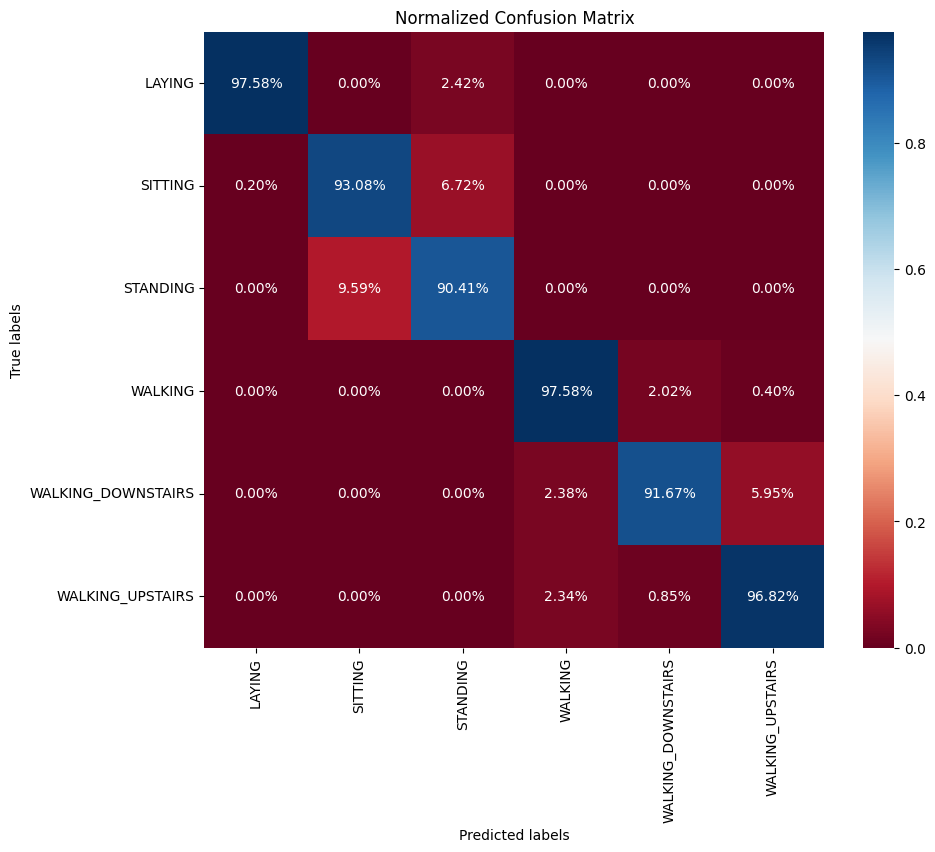

In [37]:
def evaluate_model(model, X_test, Y_test):
    Y_pred_prob = model.predict(X_test)
    Y_pred = np.argmax(Y_pred_prob, axis=1)
    testing_accuracy = accuracy_score(Y_test, Y_pred)
    print("Testing Accuracy:", testing_accuracy)
    conf_matrix = confusion_matrix(Y_test, Y_pred)

    # Normalize confusion matrix
    conf_matrix_norm = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    # Display confusion matrix as heatmap with percentages
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix_norm, annot=True, fmt='.2%', cmap='RdBu',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Normalized Confusion Matrix')
    plt.show()

    return testing_accuracy, conf_matrix

# Evaluate Bidirectional RNN model
testing_accuracy, conf_matrix = evaluate_model(bidirectional_rnn_model, X_test_reshaped, Y_test_encoded)
